## (0) Settings and Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [3]:
df = pd.read_csv("../../data/treated/tweet_emotions_ptbr_treated.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...


In [ ]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_scores = results['test_f1_macro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Vectorization Hiperparams Tests

In [5]:
X_text = df['CLEAN_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(8693,) (1863,) (1863,)


In [6]:
vect = TfidfVectorizer()

vect.fit_transform(X_text_train)

print(X_text_train.shape)

(8693,)


In [22]:
tfidf_params = {
    "max_features": [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000],
    "ngram_range": [(1,1), (1,2), (1,3)],
    "max_df": [1.0, 0.9, 0.8, 0.7],
    "min_df": [1, 10, 25],
}

models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

In [23]:
def run_experiments_tfidf_model(model_name, model, param_name, values,
                                X_text_train, y_train, current_tfidf_config
):
    results = []

    print("\n" + "#"*120)
    print(f"🔍 MODELO: {model_name} | Testando parâmetro: {param_name}")
    print("#"*120)
    
    for val in values:
        print(f"\n>> Testing {param_name} = {val}")

        config = current_tfidf_config.copy()
        config[param_name] = val

        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(**config)),
            ("model", model)
        ])

        cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

        results.append({
            "model": model_name,
            "tfidf_config": config,
            "param": param_name,
            "value": val,
            
            "CV_Accuracy_mean":  cv_res["Accuracy"][0],
            "CV_Accuracy_std":   cv_res["Accuracy"][1],

            "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
            "CV_Precision_macro_std":   cv_res["Precision_macro"][1],

            "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
            "CV_Recall_macro_std":   cv_res["Recall_macro"][1],

            "CV_F1_macro_mean":  cv_res["F1_macro"][0],
            "CV_F1_macro_std":   cv_res["F1_macro"][1],
        })

    plot_values = [str(r["value"]) for r in results]
    plot_f1 = [r["CV_F1_macro_mean"] for r in results]

    plt.figure(figsize=(8,5))
    plt.plot(plot_values, plot_f1, marker="o")
    plt.title(f"{model_name} – effect of {param_name} on F1 (CV)")
    plt.xlabel(param_name)
    plt.ylabel("F1")
    plt.grid(True)
    plt.show()

    best = max(results, key=lambda x: x["CV_F1_macro_mean"])

    print(f"\n🏆 BEST RESULTS FOR {param_name}: {best['value']}")
    print(f"   📊 Accuracy:  {best['CV_Accuracy_mean']:.4f} (±{best['CV_Accuracy_std']:.4f})")
    print(f"   📊 Precision_macro:  {best['CV_Precision_macro_mean']:.4f} (±{best['CV_Precision_macro_std']:.4f})")
    print(f"   📊 Recall_macro:  {best['CV_Recall_macro_mean']:.4f} (±{best['CV_Recall_macro_std']:.4f})")
    print(f"   📊 F1_macro:  {best['CV_F1_macro_mean']:.4f} (±{best['CV_F1_macro_std']:.4f})")

    return best, results


🏁 STARTING MODEL OPTIMIZATION: LogisticRegression

########################################################################################################################
🔍 MODELO: LogisticRegression | Testando parâmetro: max_features
########################################################################################################################

>> Testing max_features = 1000

>> Testing max_features = 2000

>> Testing max_features = 3000

>> Testing max_features = 4000

>> Testing max_features = 5000

>> Testing max_features = 6000

>> Testing max_features = 7000

>> Testing max_features = 8000


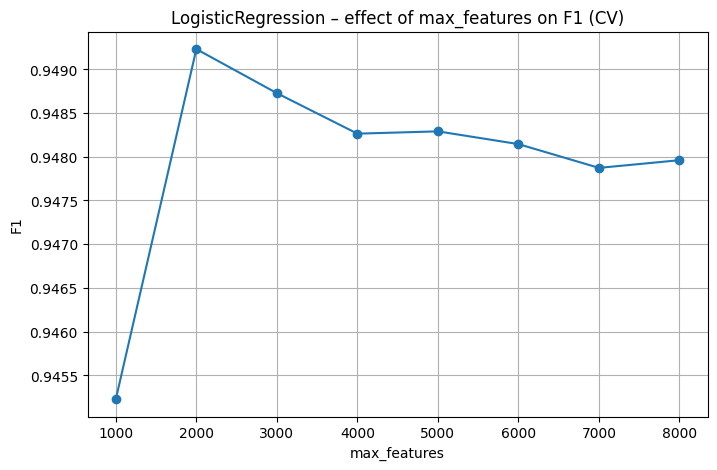


🏆 BEST RESULTS FOR max_features: 2000
   📊 Accuracy:  0.9485 (±0.0052)
   📊 Precision_macro:  0.9502 (±0.0049)
   📊 Recall_macro:  0.9490 (±0.0051)
   📊 F1_macro:  0.9492 (±0.0051)

########################################################################################################################
🔍 MODELO: LogisticRegression | Testando parâmetro: ngram_range
########################################################################################################################

>> Testing ngram_range = (1, 1)

>> Testing ngram_range = (1, 2)

>> Testing ngram_range = (1, 3)


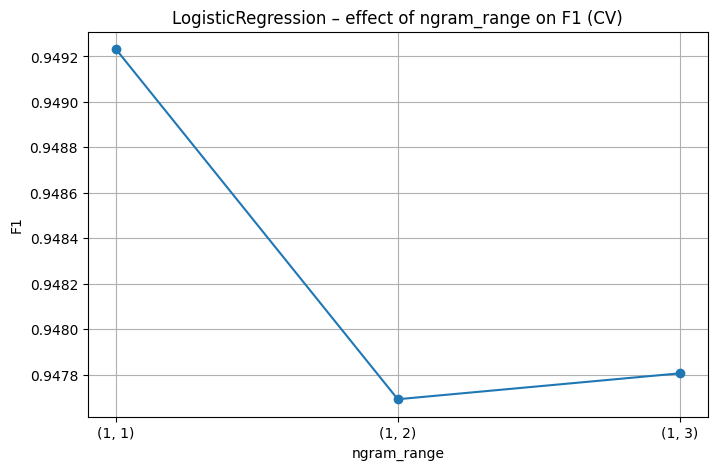


🏆 BEST RESULTS FOR ngram_range: (1, 1)
   📊 Accuracy:  0.9485 (±0.0052)
   📊 Precision_macro:  0.9502 (±0.0049)
   📊 Recall_macro:  0.9490 (±0.0051)
   📊 F1_macro:  0.9492 (±0.0051)

########################################################################################################################
🔍 MODELO: LogisticRegression | Testando parâmetro: max_df
########################################################################################################################

>> Testing max_df = 1.0

>> Testing max_df = 0.9

>> Testing max_df = 0.8

>> Testing max_df = 0.7


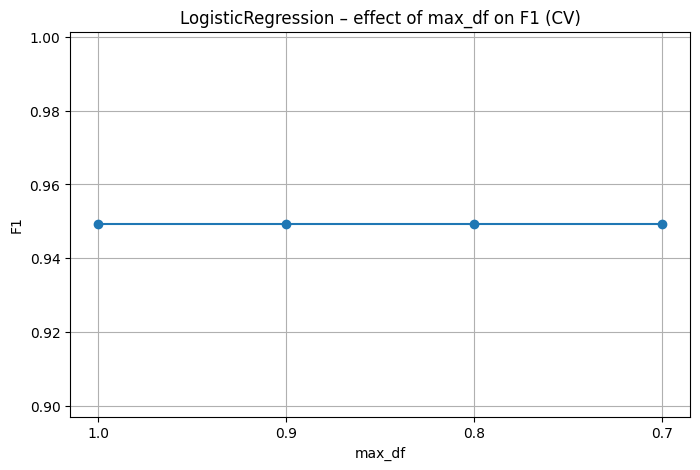


🏆 BEST RESULTS FOR max_df: 1.0
   📊 Accuracy:  0.9485 (±0.0052)
   📊 Precision_macro:  0.9502 (±0.0049)
   📊 Recall_macro:  0.9490 (±0.0051)
   📊 F1_macro:  0.9492 (±0.0051)

########################################################################################################################
🔍 MODELO: LogisticRegression | Testando parâmetro: min_df
########################################################################################################################

>> Testing min_df = 1

>> Testing min_df = 10

>> Testing min_df = 25


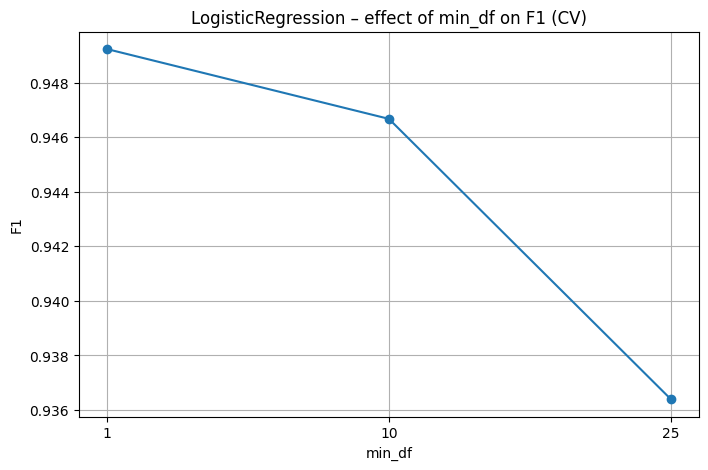


🏆 BEST RESULTS FOR min_df: 1
   📊 Accuracy:  0.9485 (±0.0052)
   📊 Precision_macro:  0.9502 (±0.0049)
   📊 Recall_macro:  0.9490 (±0.0051)
   📊 F1_macro:  0.9492 (±0.0051)

🏁 STARTING MODEL OPTIMIZATION: RidgeClassifier

########################################################################################################################
🔍 MODELO: RidgeClassifier | Testando parâmetro: max_features
########################################################################################################################

>> Testing max_features = 1000

>> Testing max_features = 2000

>> Testing max_features = 3000

>> Testing max_features = 4000

>> Testing max_features = 5000

>> Testing max_features = 6000

>> Testing max_features = 7000

>> Testing max_features = 8000


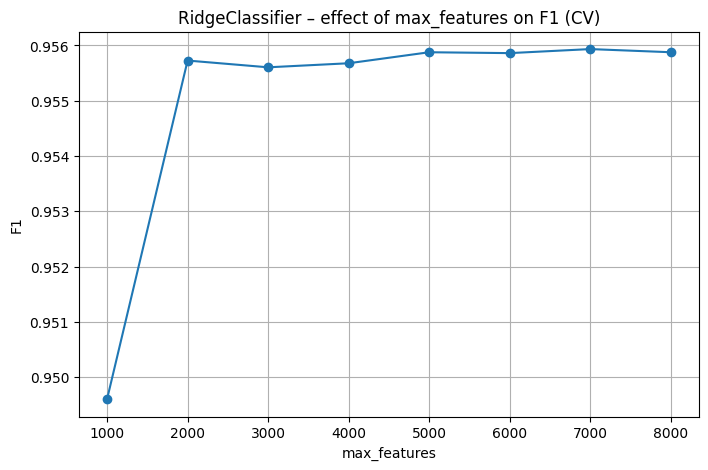


🏆 BEST RESULTS FOR max_features: 7000
   📊 Accuracy:  0.9556 (±0.0046)
   📊 Precision_macro:  0.9566 (±0.0045)
   📊 Recall_macro:  0.9559 (±0.0046)
   📊 F1_macro:  0.9559 (±0.0046)

########################################################################################################################
🔍 MODELO: RidgeClassifier | Testando parâmetro: ngram_range
########################################################################################################################

>> Testing ngram_range = (1, 1)

>> Testing ngram_range = (1, 2)

>> Testing ngram_range = (1, 3)


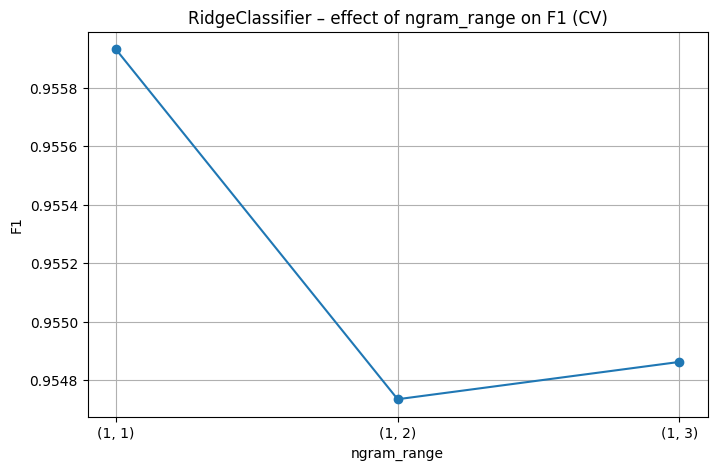


🏆 BEST RESULTS FOR ngram_range: (1, 1)
   📊 Accuracy:  0.9556 (±0.0046)
   📊 Precision_macro:  0.9566 (±0.0045)
   📊 Recall_macro:  0.9559 (±0.0046)
   📊 F1_macro:  0.9559 (±0.0046)

########################################################################################################################
🔍 MODELO: RidgeClassifier | Testando parâmetro: max_df
########################################################################################################################

>> Testing max_df = 1.0

>> Testing max_df = 0.9

>> Testing max_df = 0.8

>> Testing max_df = 0.7


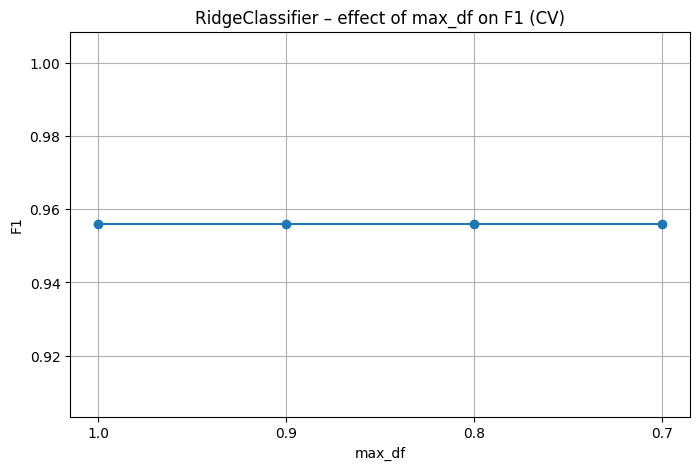


🏆 BEST RESULTS FOR max_df: 1.0
   📊 Accuracy:  0.9556 (±0.0046)
   📊 Precision_macro:  0.9566 (±0.0045)
   📊 Recall_macro:  0.9559 (±0.0046)
   📊 F1_macro:  0.9559 (±0.0046)

########################################################################################################################
🔍 MODELO: RidgeClassifier | Testando parâmetro: min_df
########################################################################################################################

>> Testing min_df = 1

>> Testing min_df = 10

>> Testing min_df = 25


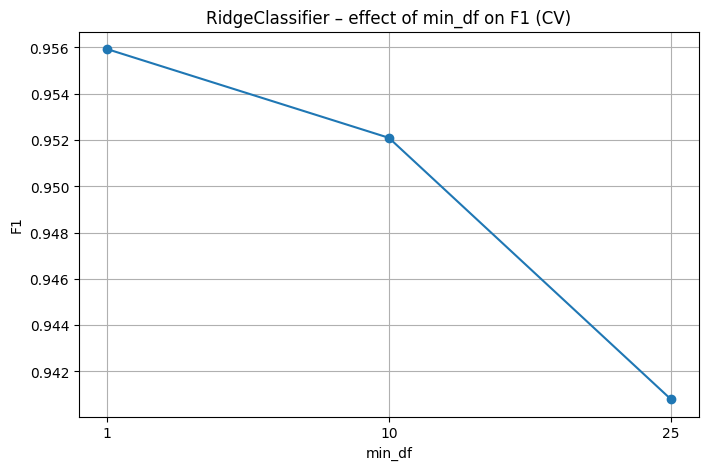


🏆 BEST RESULTS FOR min_df: 1
   📊 Accuracy:  0.9556 (±0.0046)
   📊 Precision_macro:  0.9566 (±0.0045)
   📊 Recall_macro:  0.9559 (±0.0046)
   📊 F1_macro:  0.9559 (±0.0046)

🏁 STARTING MODEL OPTIMIZATION: LinearSVC

########################################################################################################################
🔍 MODELO: LinearSVC | Testando parâmetro: max_features
########################################################################################################################

>> Testing max_features = 1000

>> Testing max_features = 2000

>> Testing max_features = 3000

>> Testing max_features = 4000

>> Testing max_features = 5000

>> Testing max_features = 6000

>> Testing max_features = 7000

>> Testing max_features = 8000


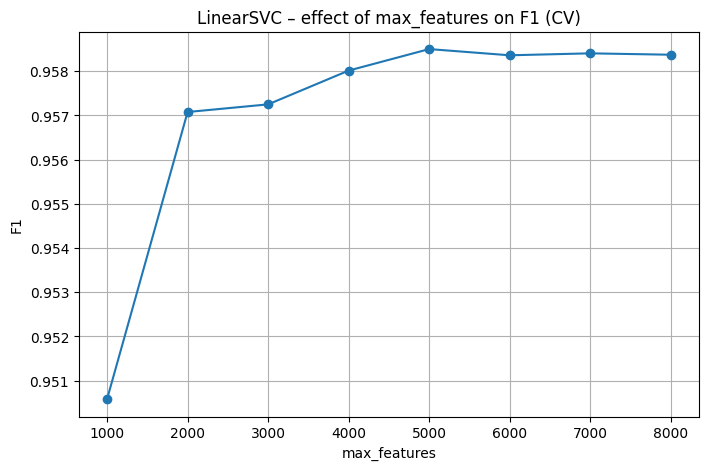


🏆 BEST RESULTS FOR max_features: 5000
   📊 Accuracy:  0.9581 (±0.0045)
   📊 Precision_macro:  0.9589 (±0.0044)
   📊 Recall_macro:  0.9585 (±0.0045)
   📊 F1_macro:  0.9585 (±0.0045)

########################################################################################################################
🔍 MODELO: LinearSVC | Testando parâmetro: ngram_range
########################################################################################################################

>> Testing ngram_range = (1, 1)

>> Testing ngram_range = (1, 2)

>> Testing ngram_range = (1, 3)


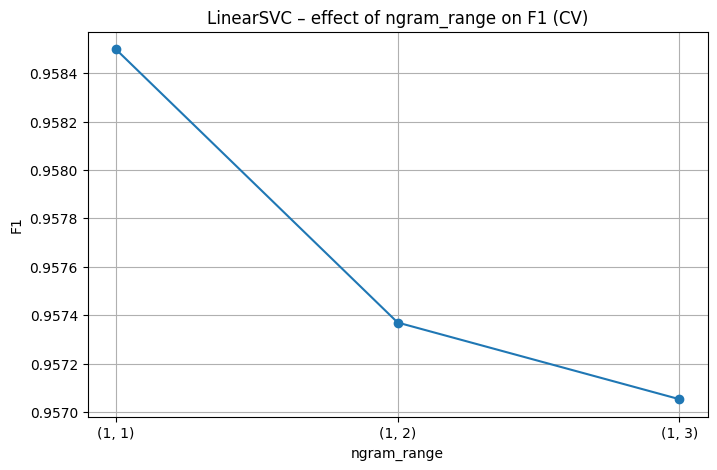


🏆 BEST RESULTS FOR ngram_range: (1, 1)
   📊 Accuracy:  0.9581 (±0.0045)
   📊 Precision_macro:  0.9589 (±0.0044)
   📊 Recall_macro:  0.9585 (±0.0045)
   📊 F1_macro:  0.9585 (±0.0045)

########################################################################################################################
🔍 MODELO: LinearSVC | Testando parâmetro: max_df
########################################################################################################################

>> Testing max_df = 1.0

>> Testing max_df = 0.9

>> Testing max_df = 0.8

>> Testing max_df = 0.7


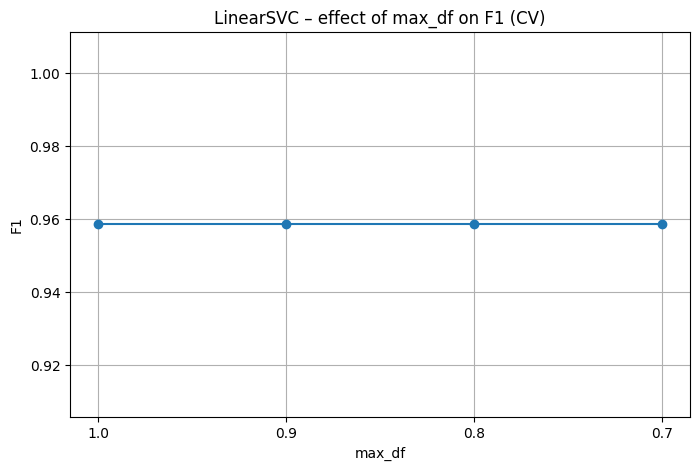


🏆 BEST RESULTS FOR max_df: 1.0
   📊 Accuracy:  0.9581 (±0.0045)
   📊 Precision_macro:  0.9589 (±0.0044)
   📊 Recall_macro:  0.9585 (±0.0045)
   📊 F1_macro:  0.9585 (±0.0045)

########################################################################################################################
🔍 MODELO: LinearSVC | Testando parâmetro: min_df
########################################################################################################################

>> Testing min_df = 1

>> Testing min_df = 10

>> Testing min_df = 25


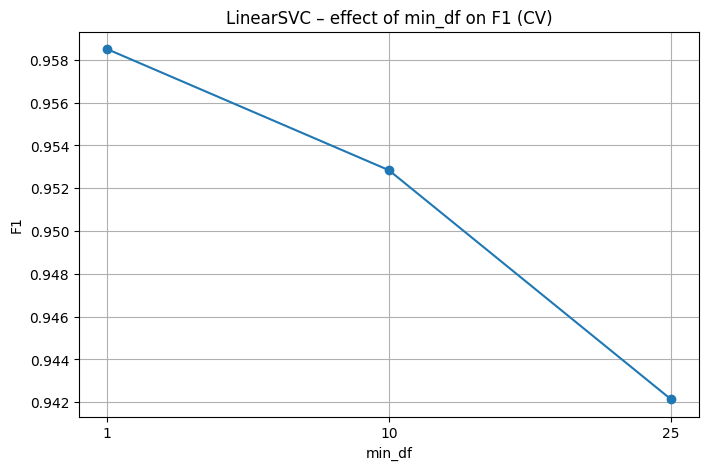


🏆 BEST RESULTS FOR min_df: 1
   📊 Accuracy:  0.9581 (±0.0045)
   📊 Precision_macro:  0.9589 (±0.0044)
   📊 Recall_macro:  0.9585 (±0.0045)
   📊 F1_macro:  0.9585 (±0.0045)

🏁 STARTING MODEL OPTIMIZATION: RandomForest

########################################################################################################################
🔍 MODELO: RandomForest | Testando parâmetro: max_features
########################################################################################################################

>> Testing max_features = 1000

>> Testing max_features = 2000

>> Testing max_features = 3000

>> Testing max_features = 4000

>> Testing max_features = 5000

>> Testing max_features = 6000

>> Testing max_features = 7000

>> Testing max_features = 8000


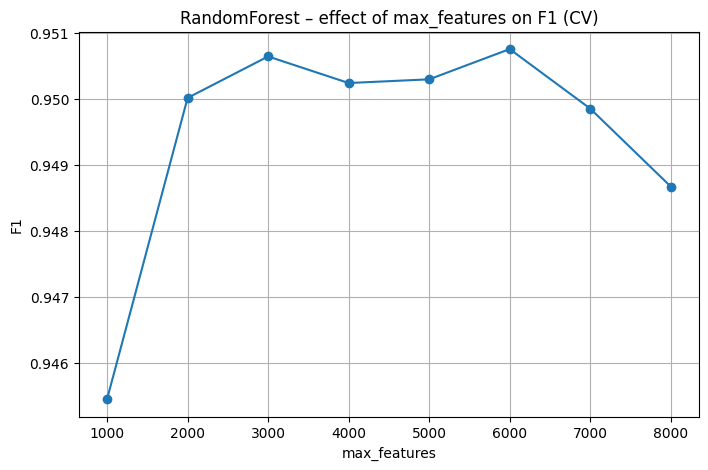


🏆 BEST RESULTS FOR max_features: 6000
   📊 Accuracy:  0.9501 (±0.0044)
   📊 Precision_macro:  0.9521 (±0.0039)
   📊 Recall_macro:  0.9505 (±0.0043)
   📊 F1_macro:  0.9508 (±0.0042)

########################################################################################################################
🔍 MODELO: RandomForest | Testando parâmetro: ngram_range
########################################################################################################################

>> Testing ngram_range = (1, 1)

>> Testing ngram_range = (1, 2)

>> Testing ngram_range = (1, 3)


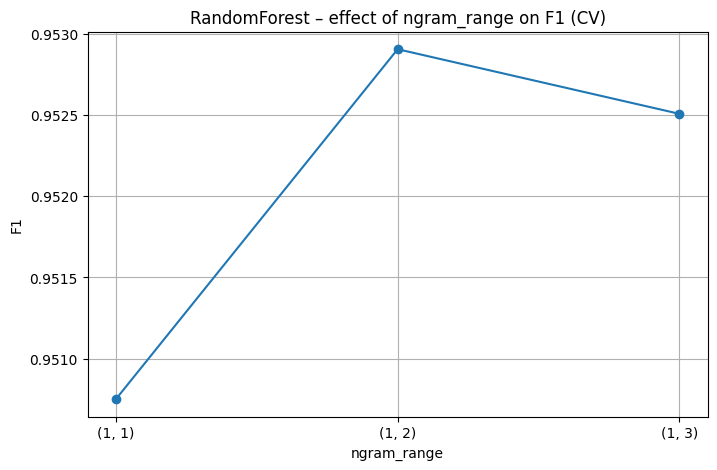


🏆 BEST RESULTS FOR ngram_range: (1, 2)
   📊 Accuracy:  0.9521 (±0.0049)
   📊 Precision_macro:  0.9544 (±0.0046)
   📊 Recall_macro:  0.9524 (±0.0049)
   📊 F1_macro:  0.9529 (±0.0048)

########################################################################################################################
🔍 MODELO: RandomForest | Testando parâmetro: max_df
########################################################################################################################

>> Testing max_df = 1.0

>> Testing max_df = 0.9

>> Testing max_df = 0.8

>> Testing max_df = 0.7


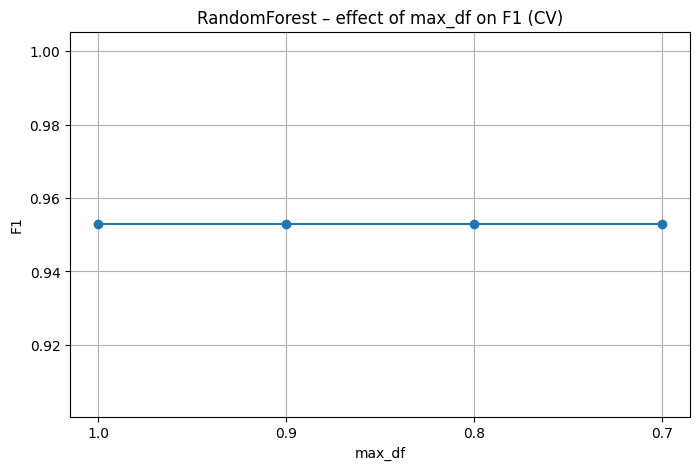


🏆 BEST RESULTS FOR max_df: 1.0
   📊 Accuracy:  0.9521 (±0.0049)
   📊 Precision_macro:  0.9544 (±0.0046)
   📊 Recall_macro:  0.9524 (±0.0049)
   📊 F1_macro:  0.9529 (±0.0048)

########################################################################################################################
🔍 MODELO: RandomForest | Testando parâmetro: min_df
########################################################################################################################

>> Testing min_df = 1

>> Testing min_df = 10

>> Testing min_df = 25


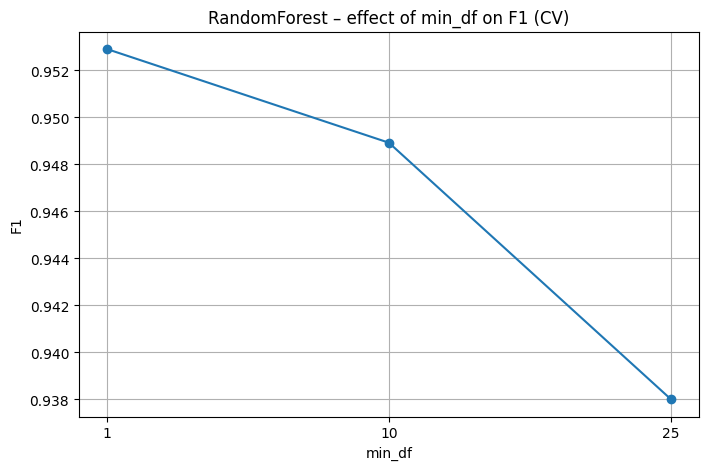


🏆 BEST RESULTS FOR min_df: 1
   📊 Accuracy:  0.9521 (±0.0049)
   📊 Precision_macro:  0.9544 (±0.0046)
   📊 Recall_macro:  0.9524 (±0.0049)
   📊 F1_macro:  0.9529 (±0.0048)

🏁 STARTING MODEL OPTIMIZATION: XGBClassifier

########################################################################################################################
🔍 MODELO: XGBClassifier | Testando parâmetro: max_features
########################################################################################################################

>> Testing max_features = 1000

>> Testing max_features = 2000

>> Testing max_features = 3000

>> Testing max_features = 4000

>> Testing max_features = 5000

>> Testing max_features = 6000

>> Testing max_features = 7000

>> Testing max_features = 8000


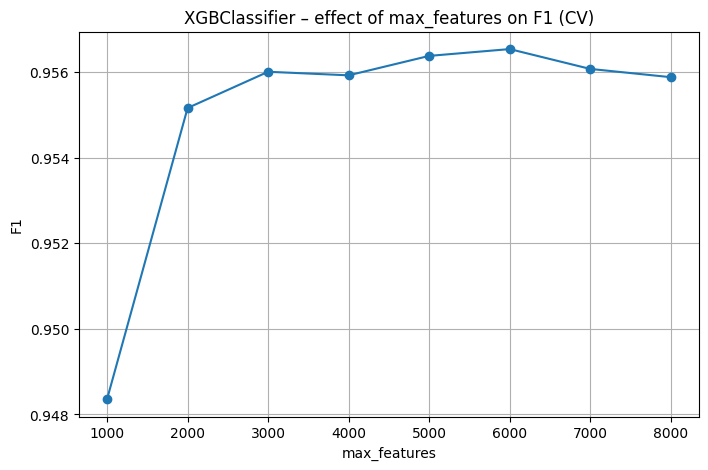


🏆 BEST RESULTS FOR max_features: 6000
   📊 Accuracy:  0.9556 (±0.0045)
   📊 Precision_macro:  0.9580 (±0.0045)
   📊 Recall_macro:  0.9560 (±0.0044)
   📊 F1_macro:  0.9565 (±0.0044)

########################################################################################################################
🔍 MODELO: XGBClassifier | Testando parâmetro: ngram_range
########################################################################################################################

>> Testing ngram_range = (1, 1)

>> Testing ngram_range = (1, 2)

>> Testing ngram_range = (1, 3)


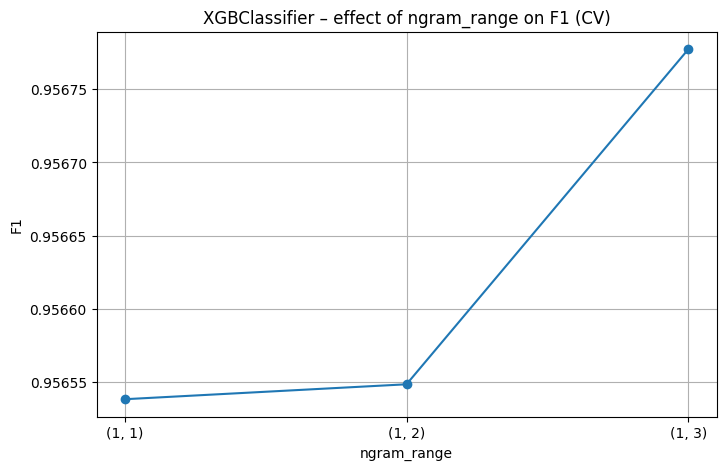


🏆 BEST RESULTS FOR ngram_range: (1, 3)
   📊 Accuracy:  0.9559 (±0.0043)
   📊 Precision_macro:  0.9581 (±0.0042)
   📊 Recall_macro:  0.9563 (±0.0043)
   📊 F1_macro:  0.9568 (±0.0042)

########################################################################################################################
🔍 MODELO: XGBClassifier | Testando parâmetro: max_df
########################################################################################################################

>> Testing max_df = 1.0

>> Testing max_df = 0.9

>> Testing max_df = 0.8

>> Testing max_df = 0.7


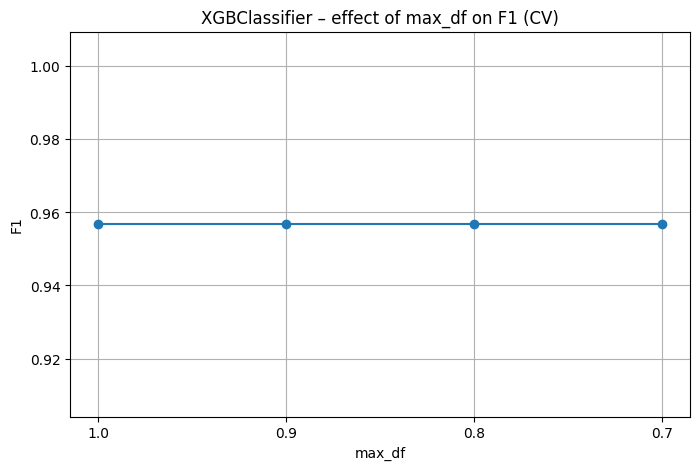


🏆 BEST RESULTS FOR max_df: 1.0
   📊 Accuracy:  0.9559 (±0.0043)
   📊 Precision_macro:  0.9581 (±0.0042)
   📊 Recall_macro:  0.9563 (±0.0043)
   📊 F1_macro:  0.9568 (±0.0042)

########################################################################################################################
🔍 MODELO: XGBClassifier | Testando parâmetro: min_df
########################################################################################################################

>> Testing min_df = 1

>> Testing min_df = 10

>> Testing min_df = 25


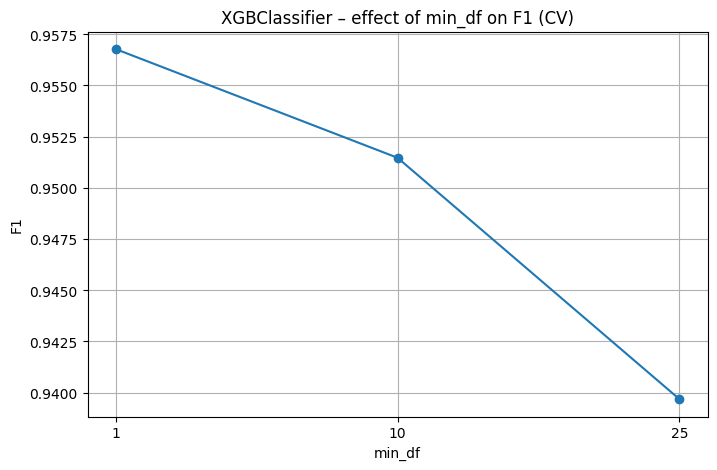


🏆 BEST RESULTS FOR min_df: 1
   📊 Accuracy:  0.9559 (±0.0043)
   📊 Precision_macro:  0.9581 (±0.0042)
   📊 Recall_macro:  0.9563 (±0.0043)
   📊 F1_macro:  0.9568 (±0.0042)


In [24]:
best_model = []
all_tests = []

for model_name, model in models_for_testing.items():
    print("\n" + "="*140)
    print(f"🏁 STARTING MODEL OPTIMIZATION: {model_name}")
    print("="*140)

    tfidf_config = {
        "ngram_range": (1,1),
        "max_df": 1.0,
        "min_df": 1,
        "max_features": None
    }

    for param_name, values in tfidf_params.items():
        best_value, results_param = run_experiments_tfidf_model(
            model_name=model_name,
            model=model,
            param_name=param_name,
            values=values,
            X_text_train=X_text_train,
            y_train=y_train,
            current_tfidf_config=tfidf_config
        )

        tfidf_config[param_name] = best_value["value"]
        all_tests.extend(results_param)